# State_History :Time Travel

## Review:
### breakpoints - Static and Dynamic
- Human in the loop to
      - Approve : Approve the operation after an interrupt by providing the state to the user
      - Debugging: Debug by rewinding the graph to avoid issues
      - Edit: provide human feedback by directly updating or modifying the state

- Static inturrupt - place it before or after the node
- Dynamic intrrupt - place in any node and wait for the the approval

## Goal: Time travel through checkpoints:
- Explore the state to go throught the history
- modify and edit the state
- View, re-play and fork from past states

### why?:
- Supports debugging

# Visualization :
<img src="../../Images/checkpoint1.png" width="800">


## Current state - get current state using graph.get_State(thread) function.

## History - get graph gistory using graph.get_state_history(thread) function

### To use time travel, you need:

- Checkpointing enabled
    - Local: pass a checkpointer (e.g. InMemorySaver, DB, etc.) to compile()
    - LangSmith / LangGraph Cloud: persistence is built-in

- A thread_id created 
    - This identifies the “timeline” (conversation/run) you’re time-traveling within
 
## Time travel via Replay (conceptual steps)
**Goal**: Re-run from a previous checkpoint to see what happens again.
1. Run graph as usual
2. Pick a checkpoint to replay from
3. Replay from Nodes after that checkpoint 
Note: Any LLM calls / tools / interrupts after that point happen again (and may differ in their result)

## Time travel via Fork (conceptual steps)
**Goal**: Start a new branch from a past checkpoint, possibly with changes.
1. Run graph as usual
2. Pick a checkpoint to Fork from
3. Create a fork (initial state of the fork is the current state of the checkpoint)
4. Run the forked branch
Note: Nodes after the checkpoint start fresh and can be used to try new logic


#### Build a graph agent that uses LLM with tools 

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [3]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHPf4X0Bi5K7AyPD9yT84sPbwOs6Zhsec1fea4vNIgaWe34w4iziboMscXxPLS'}}]

In [4]:
# define tools

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

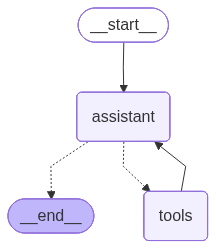

In [7]:
# Build a graph

from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition



# define node functions


# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}


# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
builder.add_edge("assistant", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

# Show
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 20 and 4")}

# Thread
thread = {"configurable": {"thread_id": "2"}}

# Run the graph 
for event in graph.stream(initial_input, thread, stream_mode="values"):
    print(event['messages'][-1])
    print("\n\n")

[HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a')]



[HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 20}'}, '__gemini_function_call_thought_signatures__': {'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b': 'EjQKMgEMOdbHFtY0DS+3tTSVD5rNsz72SwU47/8fH2+mtqZCsU64mJmdBPoF0qqlu3UmreW1'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de9eb-2602-79b3-8694-30b4bbc2cb59-0', tool_calls=[{'name': 'multiply', 'args': {'b': 4, 'a': 20}, 'id': 'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 17, 'total_tokens': 238, 'input_token_details': 

## Get current state, thred id and state history

In [11]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 20}'}, '__gemini_function_call_thought_signatures__': {'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b': 'EjQKMgEMOdbHFtY0DS+3tTSVD5rNsz72SwU47/8fH2+mtqZCsU64mJmdBPoF0qqlu3UmreW1'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de9eb-2602-79b3-8694-30b4bbc2cb59-0', tool_calls=[{'name': 'multiply', 'args': {'b': 4, 'a': 20}, 'id': 'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 17, 'total_tokens': 238, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='80', name='multiply', id='b499f749-1343-424f-ba58-5f697c79

In [18]:
# All state
All_state = [s for s in graph.get_state_history(thread)]
All_state

[StateSnapshot(values={'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 20}'}, '__gemini_function_call_thought_signatures__': {'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b': 'EjQKMgEMOdbHFtY0DS+3tTSVD5rNsz72SwU47/8fH2+mtqZCsU64mJmdBPoF0qqlu3UmreW1'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de9eb-2602-79b3-8694-30b4bbc2cb59-0', tool_calls=[{'name': 'multiply', 'args': {'b': 4, 'a': 20}, 'id': 'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 17, 'total_tokens': 238, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='80', name='multiply', id='b499f749-1343-424f-ba58-5f697c7

## First element in the history is the current state we got from get_state()


In [15]:

Curresnt_state = All_state[0]
Curresnt_state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 20}'}, '__gemini_function_call_thought_signatures__': {'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b': 'EjQKMgEMOdbHFtY0DS+3tTSVD5rNsz72SwU47/8fH2+mtqZCsU64mJmdBPoF0qqlu3UmreW1'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de9eb-2602-79b3-8694-30b4bbc2cb59-0', tool_calls=[{'name': 'multiply', 'args': {'b': 4, 'a': 20}, 'id': 'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 17, 'total_tokens': 238, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='80', name='multiply', id='b499f749-1343-424f-ba58-5f697c79

In [16]:
# ## Get State for assistant node 

All_state[-2]

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a')]}, next=('assistant',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f146538-4fdb-65f1-8000-ce596bcbb0e5'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-02T18:19:55.264561+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f146538-4fdb-65f0-bfff-c72dec5d06ca'}}, tasks=(PregelTask(id='ca5b1d45-64b5-06c0-e994-b5830030b1bc', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 20}'}, '__gemini_function_call_thought_signatures__': {'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b': 'EjQKMgEMOdbHFtY0DS+3tTSVD5rNsz72SwU47/8fH2+mtqZCsU64mJmdBPoF0qqlu3UmreW1'}}, r

## Replay

<img src="../../Images/state_checkpoints_memory.png" width="800">

## replay from assistant node

- use the config containing checkpoint id going to the assistant node
- re-run the graph from selected checkpoint
- To replay from here, we simply pass the config back to the agent!
- The graph knows that this checkpoint has aleady been executed.
- It just re-plays from this checkpoint!

## Replay basically re-running the graph from a point wnd expecting to show same or different result .

In [27]:
Checkpoint = All_state[-3].config
Checkpoint

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f146538-54dc-6b58-8001-dc868c49a331'}}

In [28]:
# replay with graph.stream -passing the checkpoint id
for chunk in graph.stream(None, Checkpoint , stream_mode="values"):
    print(chunk)
    print("/n")

{'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 4, "a": 20}'}, '__gemini_function_call_thought_signatures__': {'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b': 'EjQKMgEMOdbHFtY0DS+3tTSVD5rNsz72SwU47/8fH2+mtqZCsU64mJmdBPoF0qqlu3UmreW1'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de9eb-2602-79b3-8694-30b4bbc2cb59-0', tool_calls=[{'name': 'multiply', 'args': {'b': 4, 'a': 20}, 'id': 'c7718ae9-0d7b-4cf5-b68e-790c3ea8082b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 17, 'total_tokens': 238, 'input_token_details': {'cache_read': 0}})]}
/n
{'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata=

In [29]:
for chunk in graph.stream(None, Checkpoint , stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  multiply (c7718ae9-0d7b-4cf5-b68e-790c3ea8082b)
 Call ID: c7718ae9-0d7b-4cf5-b68e-790c3ea8082b
  Args:
    b: 4
    a: 20
================================= Tool Message =================================
Name: multiply

80
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 20 and 4 is 80.', 'extras': {'signature': 'EjQKMgEMOdbHPQxCMpjnxkdQo/XZXF4l+YdvF0SGV/xJcoFmA+ma2oKAsSezcHBkz/h7VBd2'}}]


## Forking: create a branch from a checkpoint

<img src="../../Images/forking.png" width="1000">

1. Forking current checkpoint with new state- graph.state_update(thread,{'messages': add 1 and 2})
2. Forking a specified checkpoint with new state - graph.state_update(checkpoint, thread,{'messages': add 1 and 2})

## Fork form the checkpoint again -
```
{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f146538-54dc-6b58-8001-dc868c49a331'}}
```

- Update the state with new input

In [33]:
# checkpoint to tselect from 
Checkpoint = All_state[-2].config
Checkpoint

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f146538-4fdb-65f1-8000-ce596bcbb0e5'}}

In [34]:
# current state message input
input_msg = All_state[-2].values
input_msg

{'messages': [HumanMessage(content='Multiply 20 and 4', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a')]}

In [37]:
# input ID
input_id = input_msg['messages'][0].id
input_id

'9ad67f3b-9a33-4618-a643-ceec9ed5040a'

## Overwrite the state input

- We can just run update_state with the checkpoint_id supplied.
- Remember how our reducer on messages works:
    - It will append, unless we supply a message ID.
    - We supply the message ID to overwrite the message, rather than appending to state!
    - So, to overwrite the the message, we just supply the message ID, which we have to_fork.values["messages"].id.

## forked_result generates a new forked checkpoint with new ID. 


In [51]:
forked_result = graph.update_state(Checkpoint, {'messages' : [HumanMessage(content="Add 100 to 20", id=input_id)]})
forked_config = forked_result
forked_config

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f147e14-6996-695c-8001-f383ae98065c'}}

### metadata: e.g., where to go next - is perserved!
- We can see that the current state of our agent has been updated after the fork

In [52]:
# since the get state history return object use list function
forked_State = list(graph.get_state_history(thread))
forked_State

[StateSnapshot(values={'messages': [HumanMessage(content='Add 100 to 20', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a')]}, next=('assistant',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f147e14-6996-695c-8001-f383ae98065c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-04T17:47:10.285768+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f146538-4fdb-65f1-8000-ce596bcbb0e5'}}, tasks=(PregelTask(id='c1edf881-1aee-6bfb-a9ef-16971b469753', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': [HumanMessage(content='Add 1000 to 20 and then divide by 2', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'add', 'arguments': 

### First snapshot in the list shows that the state has been updated and next node to execute in **assistant**

In [53]:
forked_State[0]

StateSnapshot(values={'messages': [HumanMessage(content='Add 100 to 20', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a')]}, next=('assistant',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f147e14-6996-695c-8001-f383ae98065c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-04T17:47:10.285768+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f146538-4fdb-65f1-8000-ce596bcbb0e5'}}, tasks=(PregelTask(id='c1edf881-1aee-6bfb-a9ef-16971b469753', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

### Get current state

In [54]:
graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Add 100 to 20', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a')]}, next=('assistant',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f147e14-6996-695c-8001-f383ae98065c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-04T17:47:10.285768+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f146538-4fdb-65f1-8000-ce596bcbb0e5'}}, tasks=(PregelTask(id='c1edf881-1aee-6bfb-a9ef-16971b469753', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

## re-run while streaming runs the the graph rather than re-playing

In [55]:
for event in graph.stream(None, forked_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Add 100 to 20
================================== Ai Message ==================================

[]
Tool Calls:
  add (b9edeaae-6cfa-4b03-9069-74d31c1e0456)
 Call ID: b9edeaae-6cfa-4b03-9069-74d31c1e0456
  Args:
    b: 20
    a: 100
================================= Tool Message =================================
Name: add

120
================================== Ai Message ==================================

[{'type': 'text', 'text': '100 + 20 = 120', 'extras': {'signature': 'EjQKMgEMOdbHd0Dl0zPA3TRwVfutMMQC6tHfT4CdrUsdvp8h743MaHYSCRtcEk0UXGgk9Uy+'}}]


## Check current state 

In [57]:
Current_state = graph.get_state(thread)
Current_state

StateSnapshot(values={'messages': [HumanMessage(content='Add 100 to 20', additional_kwargs={}, response_metadata={}, id='9ad67f3b-9a33-4618-a643-ceec9ed5040a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"b": 20, "a": 100}'}, '__gemini_function_call_thought_signatures__': {'b9edeaae-6cfa-4b03-9069-74d31c1e0456': 'EjQKMgEMOdbH0If+wlwrSUQNL+596emDI+JrMXBjkecliRqNHRO9GZFVvvNhQ9+jW5PT9diE'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019df41b-00ec-7292-bd6d-ab0627134d7b-0', tool_calls=[{'name': 'add', 'args': {'b': 20, 'a': 100}, 'id': 'b9edeaae-6cfa-4b03-9069-74d31c1e0456', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 223, 'output_tokens': 19, 'total_tokens': 242, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='120', name='add', id='95888dd0-65a5-45be-ac3b-6a854665f810', tool_ca

# Time -Travel with LangSmith API